# Search for optimal partition with minimal description length based on Map equation
The original paper proposes a greedy search followed by simulated annealing, but we're implementing the fast stochastic and recursive search algorithm that was introduced in the 2009 publication "The map equation" by M. Rosvall, D. Axelsson, and C.T. Bergstrom. It's described as follows:

## Stochastic and recursive search algorithm

Core algorithm:
- Start from each node assigned to its own module
- Node movements: in random sequential order move each node to the neighboring module that results in the largest decrease of the map equation. If no improving move can be made, the node remains in its original community
- Repeat with new random sequential order until no move generates a decrease
- Network compression: rebuild the network with the modules of the last level forming the nodes of this new compressed graph, and the edges between/within communities being aggregated
- again, perform node movement optimization tand compress the network based on the resulting community assignments. Repeat until the description length cannot be decreased further

The results of the core algorithm are then improved with the following refinement strategies:

*Submodule movements*:
- Each module is treated as a network on its own, and the main algorithm is reapplied.
- Resulting submodules are moved back to their respective modules
- Main algorithm is repeated, starting from the previous module assignments but with the submodules being freely moveable.

*Single-node movements*:
- Re-assign each node to be freely movable on its own. 
- Start from the same module partition as before, and reapply the main algorithm with each node being freely movable.

Both refinements are repeated in sequence, as long as improvements can be made. The submodule movements are applied recursively, such that the algorithm splits the modules into submodules, those into subsubmodules etc until no further splits are possible. 

This main algorithm composed of core algorithm and refinements is restarted from scratch multiple times.

### Core algorithm
The core algorithm consists of 2 phases.

Phase 1:
- initially assign each node to a different communitiy ($N$ nodes -> $N$ communities)
- for each node i, consider neighbours j, check if/how much removing i from its community and putting it into j's community improves (decreases) description length
- choose neighbour merge with best improvement. If no improvement possible, i stays in its community.
- repeat sequentially for all nodes until no further improvement can be made -> Phase 1 done!

Phase 2:
- build a new network whose nodes are the communities found in phase 1
- weights of links between new nodes correspond to sum of weight of links between old nodes in the corresponding 2 communities; links between nodes of the same community lead to self-loops for this community in the new network -> Phase 2 done! Can reapply Phase 1 to new network.

Iterate Phase 1 + Phase 2 until no further improvements are obtained.
Refinement possible with submodule/single-module movements -> can be performed in sequence until no more improvements.

We implement the following functions to tackle this:
- `update_node_move_description_length()`: Computes the change in description length for a given community partition in the event that a single node is moved from its community to another community. (for phase 1) -> Tested in `Test_infomap.ipynb`.
- `node_movement_optimization()`: Basically runs the Phase 1. Sequentially goes through nodes in random order, finds the optimal move using `update_node_move_description_length()`, and repeats until no improving moves can be made. 
- `compress_network()`: Implements Phase 2. Takes the community assignment and transforms it into a new network with nodes corresponding to the communities, and aggregates the weights of the within- and between-community links into self-loops and links between nodes on the new network. -> DONE

In [1]:
# library imports
import igraph as ig
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import timeit
import warnings
import random
import sys
sys.path.append("..") # go to parent folder
import src.map_equation as meq 
from src.utils import generate_sbm, compare_partitions, visual_community_colors
import src.optimize as opt

### Node movement opimization (Phase 1)
Let's try to do the node movement optimization:
(Some mild confusion: One of the references makes it sound as though we keep sequentially going through all nodes again until no more improvements are possible, the other one suggests that we keep track of candidate nodes and, if at any point, a node has no further moves for improvement it is removed from the candidate pool, which unlike the first option sounds like it may neglect combinations where after a change in constellation a node that previously didn't have an improving move might now have one with the new, changed modules. We decided to start implementing option one, and then later we can see if the candidate pool makes sense or not.)

Test on undirected network:

In [2]:
g_test = generate_sbm(n=100, c=4, p_in=0.25, p_out=0.01, directed=False, weighted=True)
communities, L, p_mod, exit_data = opt.node_movement_optimization(g_test, returnTerms=True, verbose=True)

Initialising node movement optimization with each node in its own community.
Starting from description length: 8.538598183255392
Current best description length: 6.320289325412739
Number of nodes moved this iteration: 71
Continuing optimization.
Current best description length: 6.049854936517683
Number of nodes moved this iteration: 15
Continuing optimization.
Current best description length: 5.924411247650184
Number of nodes moved this iteration: 8
Continuing optimization.
Current best description length: 5.863511527888895
Number of nodes moved this iteration: 4
Continuing optimization.
Current best description length: 5.787155269177617
Number of nodes moved this iteration: 5
Continuing optimization.
Current best description length: 5.752738477453251
Number of nodes moved this iteration: 3
Continuing optimization.
Current best description length: 5.752738477453251
Number of nodes moved this iteration: 0
Optimization finished!
Final number of communities: 24
Final description length: 5

In [3]:
# check the new description length, should be same as before:
print("optimization function output L: ", L)
print("recomputed description length: ", meq.compute_description_length(g_test, communities))

optimization function output L:  5.752738477453251
recomputed description length:  5.752738477453251


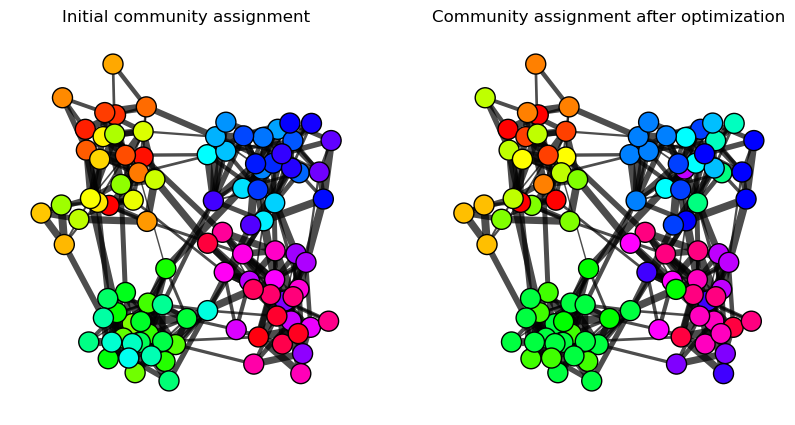

In [4]:
layout = g_test.layout('fr')
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test, layout=layout, **visual_community_colors(g_test, communities=np.arange(g_test.vcount()), skipLayout=True), target=ax[0])
ig.plot(g_test, layout=layout, **visual_community_colors(g_test, communities=communities, skipLayout=True), target=ax[1])
ax[0].set_title("Initial community assignment")
ax[1].set_title("Community assignment after optimization")
plt.show()

Test on directed network:

In [5]:
g_test_directed = generate_sbm(n=100, c=4, p_in=0.25, p_out=0.01, directed=True, weighted=True)
communities_directed, L, p_mod, exit_data = opt.node_movement_optimization(g_test_directed, returnTerms=True, verbose=True)

Initialising node movement optimization with each node in its own community.
Starting from description length: 8.508323510995243
Current best description length: 6.860636671923085
Number of nodes moved this iteration: 79
Continuing optimization.
Current best description length: 6.586021816295167
Number of nodes moved this iteration: 19
Continuing optimization.
Current best description length: 6.494076603278383
Number of nodes moved this iteration: 12
Continuing optimization.
Current best description length: 6.44573127740491
Number of nodes moved this iteration: 5
Continuing optimization.
Current best description length: 6.4350696316107
Number of nodes moved this iteration: 1
Continuing optimization.
Current best description length: 6.4350696316107
Number of nodes moved this iteration: 0
Optimization finished!
Final number of communities: 18
Final description length: 6.4350696316107


In [6]:
# check the new description length, should be same as before:
print("optimization function output L: ", L)
print("recomputed description length: ", meq.compute_description_length(g_test_directed, communities_directed))

optimization function output L:  6.4350696316107
recomputed description length:  6.4350696316107


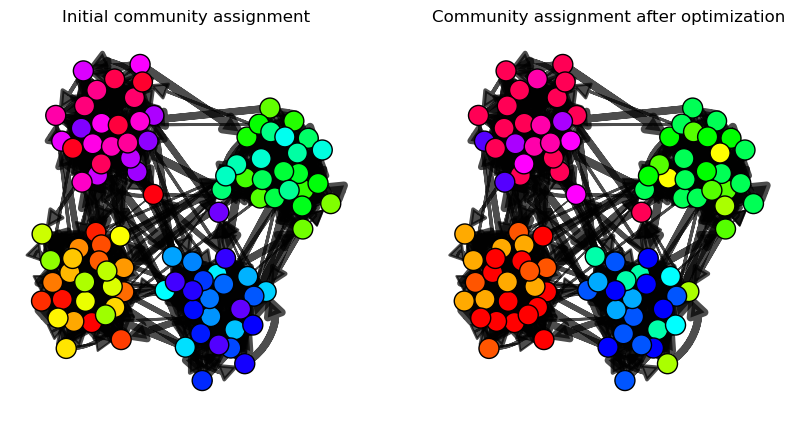

In [7]:
layout_directed = g_test_directed.layout('fr')
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test_directed, layout=layout_directed, **visual_community_colors(g_test_directed, communities=np.arange(g_test_directed.vcount()), skipLayout=True), target=ax[0])
ig.plot(g_test_directed, layout=layout_directed, **visual_community_colors(g_test_directed, communities=communities_directed, skipLayout=True), target=ax[1])
ax[0].set_title("Initial community assignment")
ax[1].set_title("Community assignment after optimization")
plt.show()

### Network compression (Phase 2)
Let's test the network compression function!

Testing with undirected test network from above:

In [8]:
g_test_compressed, unique_communities = opt.compress_network(g_test, communities, verbose=True)

Input graph has 24 unique communities, 100 nodes and 322 edges.
Creating compressed graph with 24 nodes, 131 aggregated edges.


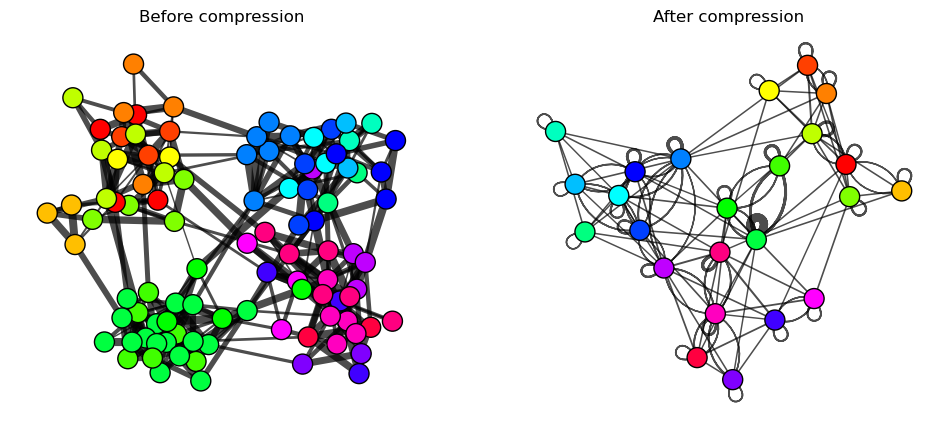

In [9]:
fig, ax = plt.subplots(ncols=2, figsize = (12, 5))
ig.plot(g_test, layout=layout, **visual_community_colors(g_test, communities=communities, skipLayout=True), target=ax[0])
ig.plot(g_test_compressed, **visual_community_colors(g_test_compressed, communities=range(g_test_compressed.vcount())), target=ax[1])
ax[0].set_title("Before compression")
ax[1].set_title("After compression")
plt.show()

In [10]:
# check the new description length:
print("Codelength before compression: ", meq.compute_description_length(g_test, communities))
print("Codelength after compression: ", meq.compute_description_length(g_test_compressed, range(g_test_compressed.vcount())))

Codelength before compression:  5.752738477453251
Codelength after compression:  3.402734433998032


In [11]:
# let's check if the difference is as expected:
L,  p, p_mod, exits = meq.compute_description_length(g_test, communities, returnTerms=True)
L_comp,  p_c, p_mod_c, exits_c = meq.compute_description_length(g_test_compressed, range(g_test_compressed.vcount()), returnTerms=True)
print(f"Before compression:\nL = {L} \nH(p) = {np.sum(meq.safe_xlogx(p))} \nH(p_mod) = {np.sum(meq.safe_xlogx(p_mod))}\n")
print(f"After compression:\nL = {L_comp} \nH(p) = {np.sum(meq.safe_xlogx(p_c))} \nH(p_mod) = {np.sum(meq.safe_xlogx(p_mod_c))}")

print("Codelength difference in theory: ", np.sum(meq.safe_xlogx(p_mod)) - np.sum(meq.safe_xlogx(p)))
print("Actual codelength difference: ", L - L_comp)

Before compression:
L = 5.752738477453251 
H(p) = -6.538598183255389 
H(p_mod) = -4.188594139800172

After compression:
L = 3.402734433998032 
H(p) = -4.188594139800172 
H(p_mod) = -4.188594139800172
Codelength difference in theory:  2.3500040434552174
Actual codelength difference:  2.350004043455219


Testing with the directed test network from above:

In [12]:
g_test_directed_compressed, unique_communities_directed = opt.compress_network(g_test_directed, communities_directed, verbose=True)

Input graph has 18 unique communities, 100 nodes and 665 edges.
Creating compressed graph with 18 nodes, 150 aggregated edges.


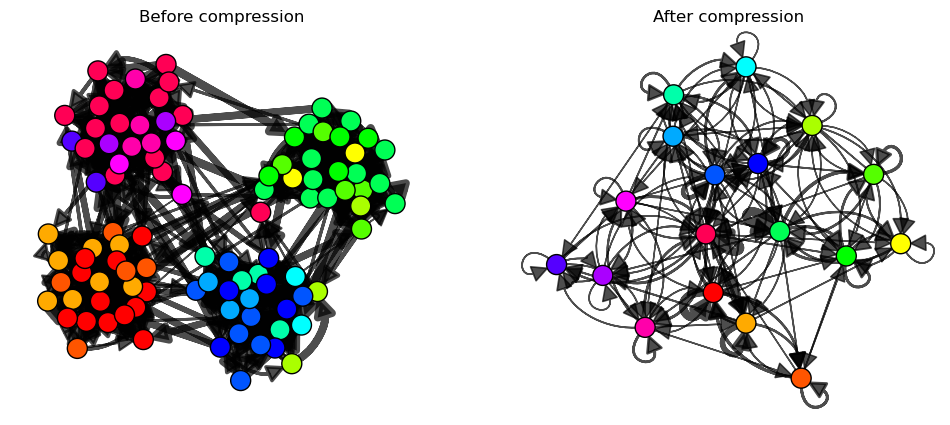

In [13]:
fig, ax = plt.subplots(ncols=2, figsize = (12, 5))
ig.plot(g_test_directed, layout=layout_directed, **visual_community_colors(g_test_directed, communities=communities_directed, skipLayout=True), target=ax[0])
ig.plot(g_test_directed_compressed, **visual_community_colors(g_test_directed_compressed, communities=range(g_test_directed_compressed.vcount())), target=ax[1])
ax[0].set_title("Before compression")
ax[1].set_title("After compression")
plt.show()

In [14]:
# check the new description length:
# we can't evaluate the difference as neatly as in the undirected case 
# bc with directed networks the changes are a lot more complex
print("Codelength before compression: ", meq.compute_description_length(g_test_directed, communities_directed))
print("Codelength after compression: ", meq.compute_description_length(g_test_directed_compressed, range(g_test_directed_compressed.vcount())))

Codelength before compression:  6.4350696316107
Codelength after compression:  4.25652239477253


### Core search algorithm
Let's put everything together to implement the core search algorithm:

Time to test them, first the undirected case:

In [15]:
comms = opt.core_search_algorithm(g_test, verbose=True)
L_test = meq.compute_description_length(g_test, comms)
print("Our best infomap description length: ", L_test)
# testing igraphs infomap implementation
comms_ig = g_test.community_infomap(edge_weights="weight")
print("Igraph's best infomap description length: ", comms_ig.codelength)
print("Description length of igraph's best community assignment computed with our function: ", meq.compute_description_length(g_test, comms_ig.membership))


--- Level 0 ------------------------------
    Current Graph: 100 nodes, 322 edges
Initialising node movement optimization with each node in its own community.
Starting from description length: 8.538598183255392
Current best description length: 6.232620346436462
Number of nodes moved this iteration: 76
Continuing optimization.
Current best description length: 5.855888702916374
Number of nodes moved this iteration: 18
Continuing optimization.
Current best description length: 5.798005805965955
Number of nodes moved this iteration: 5
Continuing optimization.
Current best description length: 5.746258454192094
Number of nodes moved this iteration: 3
Continuing optimization.
Current best description length: 5.713026639705894
Number of nodes moved this iteration: 2
Continuing optimization.
Current best description length: 5.687975132721099
Number of nodes moved this iteration: 2
Continuing optimization.
Current best description length: 5.609734684744441
Number of nodes moved this iteration: 

In [16]:
compare_partitions(comms, comms_ig.membership)

Comparing partitions:
Partition 1: 7 communities
Partition 2: 7 communities
Normalized Mututal Information: 0.9133
Adjusted Rand Index: 0.9080


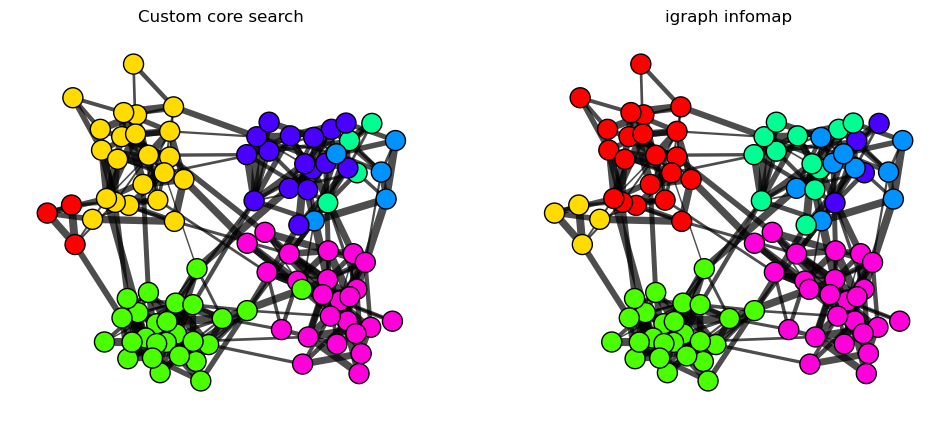

In [17]:
fig, ax = plt.subplots(ncols=2, figsize = (12, 5))
ig.plot(g_test, layout=layout, **visual_community_colors(g_test, communities=comms, skipLayout=True), target=ax[0])
ig.plot(g_test, layout=layout, **visual_community_colors(g_test, communities=comms_ig.membership, skipLayout=True), target=ax[1])
ax[0].set_title("Custom core search")
ax[1].set_title("igraph infomap")
plt.show()

Then directed:

In [18]:
comms = opt.core_search_algorithm(g_test_directed, verbose=True)
L_test = meq.compute_description_length(g_test_directed, comms)
print("Our best infomap description length: ", L_test)
# testing igraphs infomap implementation
comms_ig = g_test_directed.community_infomap(edge_weights="weight")
print("Igraph's best infomap description length: ", comms_ig.codelength)
print("Description length of igraph's best community assignment computed with our function: ", meq.compute_description_length(g_test_directed, comms_ig.membership))


--- Level 0 ------------------------------
    Current Graph: 100 nodes, 665 edges
Initialising node movement optimization with each node in its own community.
Starting from description length: 8.508323510995243
Current best description length: 6.7447375522211654
Number of nodes moved this iteration: 81
Continuing optimization.
Current best description length: 6.449337042132931
Number of nodes moved this iteration: 17
Continuing optimization.
Current best description length: 6.401521390447051
Number of nodes moved this iteration: 5
Continuing optimization.
Current best description length: 6.395782920352461
Number of nodes moved this iteration: 1
Continuing optimization.
Current best description length: 6.286468077757069
Number of nodes moved this iteration: 4
Continuing optimization.
Current best description length: 6.191795759538765
Number of nodes moved this iteration: 2
Continuing optimization.
Current best description length: 6.191795759538765
Number of nodes moved this iteration:

In [19]:
compare_partitions(comms, comms_ig.membership)

Comparing partitions:
Partition 1: 4 communities
Partition 2: 4 communities
Normalized Mututal Information: 0.9397
Adjusted Rand Index: 0.9483


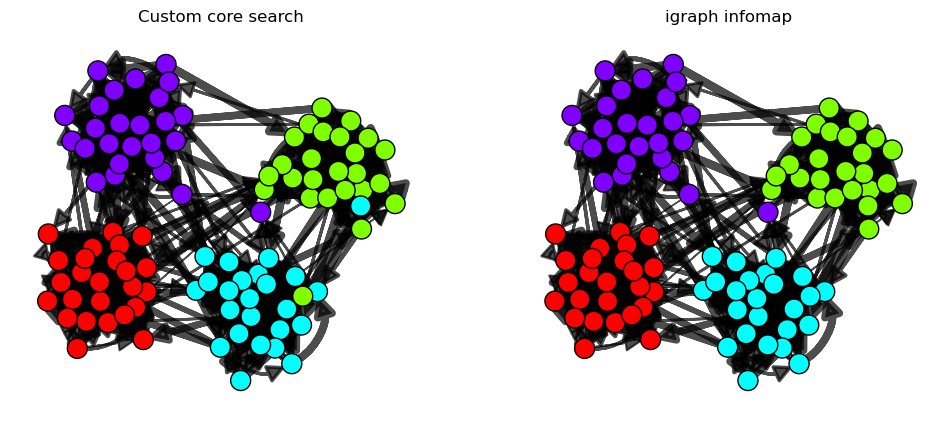

In [20]:
fig, ax = plt.subplots(ncols=2, figsize = (12, 5))
ig.plot(g_test_directed, layout=layout_directed, **visual_community_colors(g_test_directed, communities=comms, skipLayout=True), target=ax[0])
ig.plot(g_test_directed, layout=layout_directed, **visual_community_colors(g_test_directed, communities=comms_ig.membership, skipLayout=True), target=ax[1])
ax[0].set_title("Custom core search")
ax[1].set_title("igraph infomap")
plt.show()

### Refinements: Recursive submodule movements

The recursive submodule refinements are explored in a different notebook (`SubmoduleRefinement.ipynb`)